In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [3]:
tissue_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\tissue_data.xlsx"
tissue_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\Clinical Data MACE Amsterdam VA.xlsx"

In [29]:
plasma_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\plasma_data.xlsx"
plasma_labels_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\Proteomics sample labels.csv"
plasma_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\20241126 Sample ordering and info.xlsx"

In [5]:
tissue_data = pd.read_excel(tissue_dir)
tissue_data.head()

,Unnamed: 0,Protein.Group,Protein.Names,Genes,S001,S002,S003,S004,S007,S011,...,S079,S080,S081,S087,S091,S093,S095,Log2 intensity OPL3026_HeLa50ng_07,S006,S084
0,0,Q16585,SGCB_HUMAN,SGCB,9.065723,8.804035,10.121942,8.103925,7.547642,8.372846,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,P51608-2,MECP2_HUMAN,MECP2,9.233215,8.649819,10.810051,9.461354,8.213499,9.181561,...,6.590036,NaN,7.613278,5.974929,NaN,6.578975,NaN,8.069332,6.773532,6.396201
2,2,Q9H3H3,CK068_HUMAN,C11orf68,9.866450,9.624528,8.357053,9.350256,8.462160,9.632663,...,8.897010,NaN,NaN,7.205819,NaN,7.817692,NaN,9.130469,6.774161,7.462926
3,3,Q6ZT12;Q6ZT12-4,UBR3_HUMAN,UBR3,7.386442,7.298594,7.382471,7.472147,NaN,7.684338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.340680,NaN,NaN
4,4,Q96P70,IPO9_HUMAN,IPO9,9.011502,9.441655,8.578271,9.246102,8.908170,9.363126,...,8.814127,6.376397,6.931440,7.439738,8.585849,8.410148,6.14147,10.378998,6.955465,8.932941


In [10]:
print(tissue_data.head(3))
assert tissue_data['Protein.Group'].duplicated().sum() == 0, "Duplicate genes found!"

   Unnamed: 0 Protein.Group Protein.Names     Genes      S001      S002  \
0           0        Q16585    SGCB_HUMAN      SGCB  9.065723  8.804035   
1           1      P51608-2   MECP2_HUMAN     MECP2  9.233215  8.649819   
2           2        Q9H3H3   CK068_HUMAN  C11orf68  9.866450  9.624528   

        S003      S004      S007      S011  ...      S079  S080      S081  \
0  10.121942  8.103925  7.547642  8.372846  ...       NaN   NaN       NaN   
1  10.810051  9.461354  8.213499  9.181561  ...  6.590036   NaN  7.613278   
2   8.357053  9.350256  8.462160  9.632663  ...  8.897010   NaN       NaN   

       S087  S091      S093  S095  Log2 intensity OPL3026_HeLa50ng_07  \
0       NaN   NaN       NaN   NaN                                 NaN   
1  5.974929   NaN  6.578975   NaN                            8.069332   
2  7.205819   NaN  7.817692   NaN                            9.130469   

       S006      S084  
0       NaN       NaN  
1  6.773532  6.396201  
2  6.774161  7.462926  



In [8]:
unique_proteins = tissue_data['Genes'].unique()
print(tissue_data.shape)
print(len(unique_proteins))

(9726, 108)
9412


### Handling Gene Duplicates
Keep for Data exploration, for modelling, do df_gene = df.groupby("Gene").median() or keep the most abundant entry


### Global Missingness
Separate features from metadata

In [17]:
gene_symbols = tissue_data['Genes']
expression_matrix = tissue_data.drop(columns=['Genes', 'Unnamed: 0', 'Protein.Group','Protein.Names']) 

In [18]:
print("=== Global Missingness ===")
print(f"Total missing values: {expression_matrix.isnull().sum().sum()}")
print(f"Percentage missing: {expression_matrix.isnull().mean().mean()*100:.2f}%")

=== Global Missingness ===
Total missing values: 363129
Percentage missing: 35.90%


### Protein-level missingness


Top 5 proteins with most missing data:
8646    0.962617
1095    0.962617
8497    0.962617
8830    0.962617
6795    0.962617
6722    0.962617
9363    0.962617
8444    0.962617
8458    0.962617
554     0.962617
9582    0.962617
9524    0.962617
9068    0.962617
582     0.962617
8123    0.962617
9000    0.962617
617     0.962617
9590    0.962617
8952    0.962617
8872    0.962617
5899    0.962617
9393    0.962617
7673    0.962617
9123    0.962617
4882    0.962617
9537    0.962617
9611    0.962617
8308    0.962617
8851    0.953271
9329    0.953271
8827    0.953271
6064    0.953271
326     0.953271
9277    0.953271
9376    0.953271
4107    0.953271
8085    0.953271
1251    0.953271
3944    0.953271
9388    0.953271
9715    0.953271
20      0.953271
9570    0.953271
9580    0.953271
195     0.953271
7968    0.953271
9010    0.953271
2592    0.953271
5776    0.953271
2085    0.953271
dtype: float64


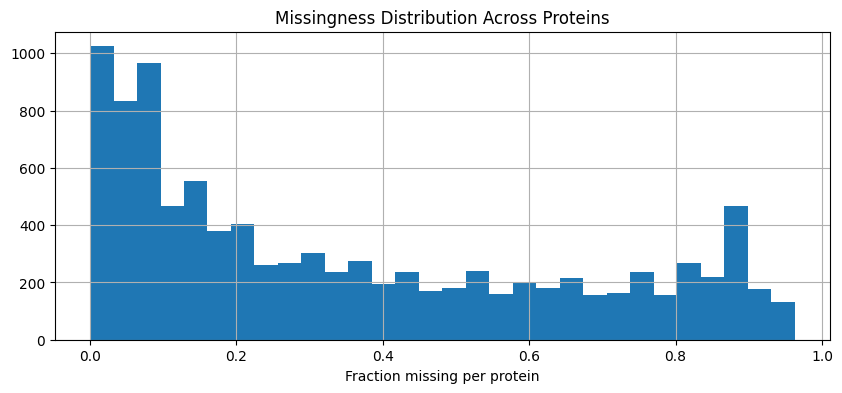

In [19]:
protein_missingness = tissue_data.iloc[:, 1:].isnull().mean(axis=1)
print("\nTop 5 proteins with most missing data:")
print(protein_missingness.sort_values(ascending=False).head(50))

# Visualize
plt.figure(figsize=(10,4))
protein_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Proteins")
plt.xlabel("Fraction missing per protein")
plt.show()

In [23]:
protein_missingness = tissue_data.iloc[:, 3:].isnull().mean(axis=1) * 100

missingness_df = pd.DataFrame({
    'protein': tissue_data.iloc[:, 3],  
    'missingness_percentage': protein_missingness
})

missingness_df.to_csv('tissue_protein_missingness.csv', index=False)

print(missingness_df.head())

    protein  missingness_percentage
0      SGCB               23.809524
1     MECP2                4.761905
2  C11orf68                5.714286
3      UBR3               29.523810
4      IPO9                0.000000


### Patient-Level Missingness


Top 5 patients with most missing data:
S081    0.932860
S091    0.838885
S095    0.836726
S008    0.834567
S080    0.826650
dtype: float64


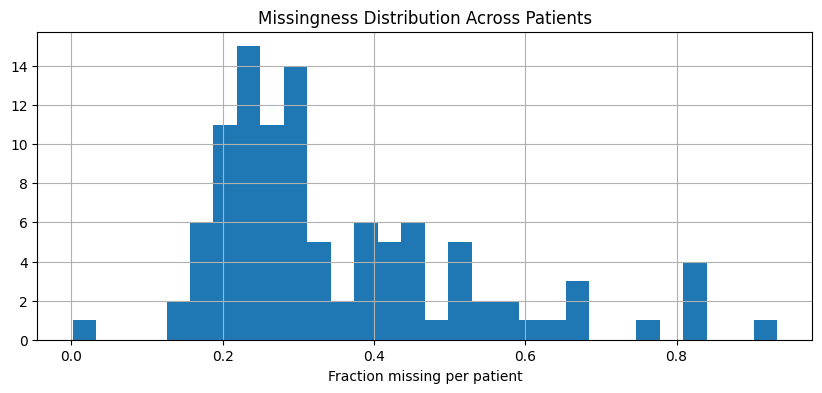

In [24]:
patient_missingness = tissue_data.iloc[:, 3:].isnull().mean(axis=0)
print("\nTop 5 patients with most missing data:")
print(patient_missingness.sort_values(ascending=False).head())

plt.figure(figsize=(10,4))
patient_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()

In [41]:
patient_missingness = tissue_data.iloc[:, 1:].isnull().mean(axis=0) * 100

missingness_sample_df = pd.DataFrame({
    'sample': tissue_data.columns[1:],
    'missingness_percentage': patient_missingness
})

missingness_sample_df.to_csv('tissue_sample_missingness.csv', index=False)

print("\nTop 10 samples with most missing data:")
print(missingness_sample_df.sort_values(by='missingness_percentage', ascending=False).head(10))



Top 10 samples with most missing data:
     sample  missingness_percentage
S081   S081               93.286037
S091   S091               83.888546
S095   S095               83.672630
S008   S008               83.456714
S080   S080               82.665022
S006   S006               75.385564
S009   S009               66.625540
S087   S087               66.317088
S005   S005               66.306806
S084   S084               63.427925


### Match tissue and plasma samples

In [47]:
plasma_data = pd.read_excel(plasma_dir)
matched_samples = [sample for sample in plasma_data.columns[1:] if sample in tissue_data.columns[1:]]
print(matched_samples)
print(len(matched_samples))

['Genes', 'S001', 'S002', 'S003', 'S004', 'S005', 'S060', 'S006', 'S007', 'S008', 'S009', 'S062', 'S010', 'S011', 'S021', 'S012', 'S013', 'S063', 'S014', 'S015', 'S023', 'S016', 'S017', 'S064', 'S018', 'S019', 'S026', 'S020', 'S022', 'S024', 'S025', 'S030', 'S053', 'S032', 'S033', 'S067', 'S034', 'S036', 'S068', 'S038', 'S039', 'S041', 'S069', 'S043', 'S091', 'S045', 'S070', 'S046', 'S047', 'S092', 'S048', 'S049', 'S071', 'S050', 'S093', 'S054', 'S055', 'S057', 'S094', 'S073', 'S074', 'S080', 'S081', 'S096', 'S075', 'S085', 'S086', 'S088', 'S089', 'S072', 'S082', 'S035', 'S078', 'S077', 'S095', 'S029', 'S037', 'S079', 'S061', 'S066', 'S031', 'S052', 'S076', 'S083', 'S087', 'S090']
86


In [36]:
print(plasma_data.shape)
tissue_data.shape

(1896, 87)


(9726, 108)

In [49]:
plasma_data.columns

Index(['Unnamed: 0', 'Genes', 'S001', 'S002', 'S003', 'S004', 'S005', 'S060',
       'S006', 'S007', 'S008', 'S009', 'S062', 'S010', 'S011', 'S021', 'S012',
       'S013', 'S063', 'S014', 'S015', 'S023', 'S016', 'S017', 'S064', 'S018',
       'S019', 'S026', 'S020', 'S022', 'S024', 'S025', 'S030', 'S053', 'S032',
       'S033', 'S067', 'S034', 'S036', 'S068', 'S038', 'S039', 'S041', 'S069',
       'S043', 'S091', 'S045', 'S070', 'S046', 'S047', 'S092', 'S048', 'S049',
       'S071', 'S050', 'S093', 'S054', 'S055', 'S057', 'S094', 'S073', 'S074',
       'S080', 'S081', 'S096', 'S075', 'S085', 'S086', 'S088', 'S089', 'S072',
       'S082', 'S035', 'S078', 'S077', 'S095', 'S029', 'S037', 'S079', 'S061',
       'S066', 'S031', 'S052', 'S076', 'S083', 'S087', 'S090'],
      dtype='str')

#### Patient-level missingness (only matched data)

(9726, 86)

Top 10 patients with most missing data:
S081    0.932860
S091    0.838885
S095    0.836726
S008    0.834567
S080    0.826650
S006    0.753856
S009    0.666255
S087    0.663171
S005    0.663068
S093    0.606107
dtype: float64


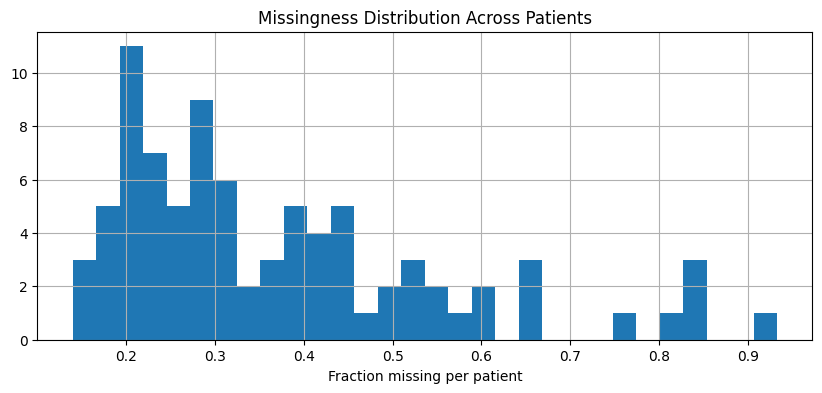

In [48]:
tissue_data_matched = tissue_data[matched_samples]
print(tissue_data_matched.shape)
patient_missingness_matched = tissue_data_matched.iloc[:, 1:].isnull().mean(axis=0)
print("\nTop 10 patients with most missing data:")
print(patient_missingness_matched.sort_values(ascending=False).head(10))

plt.figure(figsize=(10,4))
patient_missingness_matched.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()

### Remove Samples with high missingness
Patients with high missingness can artifically inflate protein missingness

In [67]:
# Dynamic threshold - keep at least 70 patients (adjust as needed)
target_keep_patients = 75 
q = (tissue_data_matched.shape[1] - 1/target_keep_patients)
print(q)
patient_threshold = np.percentile(patient_missingness_matched, q)

removed_patients = patient_missingness_matched[patient_missingness_matched > patient_threshold].index.tolist()
good_patients = patient_missingness_matched[patient_missingness_matched <= patient_threshold].index

filtered_by_patient = tissue_data_matched[['Genes'] + good_patients.tolist()] 

print(f"\n=== PATIENT FILTERING ===")
print(f"Used adaptive threshold: {patient_threshold:.1%} missing")
print(f"Removed {len(removed_patients)} patients: {removed_patients}")
print(f"Retained {len(good_patients)} patients")

85.98666666666666

=== PATIENT FILTERING ===
Used adaptive threshold: 56.0% missing
Removed 12 patients: ['S005', 'S006', 'S008', 'S009', 'S016', 'S091', 'S093', 'S080', 'S081', 'S095', 'S037', 'S087']
Retained 73 patients


In [68]:
print(filtered_by_patient.shape)

(9726, 74)


In [69]:
protein_missingness = filtered_by_patient.iloc[:, 1:].isnull().mean(axis=1)

MIN_DATA_PRESENCE = 0.80
protein_threshold = 1 - MIN_DATA_PRESENCE

good_proteins = protein_missingness[protein_missingness <= protein_threshold].index
removed_proteins = protein_missingness[protein_missingness > protein_threshold].index.tolist()

final_expression_PTPR = filtered_by_patient.loc[good_proteins]

print(f"\n=== PROTEIN FILTERING ===")
print(f"Threshold: ≥{MIN_DATA_PRESENCE:.0%} data presence (≤{protein_threshold:.0%} missing)")
print(f"Removed {len(removed_proteins)} proteins with low data presence")
print(f"Retained {len(good_proteins)} proteins")
#final_expression_PTPR.to_csv('final_expression_PTPR.csv', index=False)



=== PROTEIN FILTERING ===
Threshold: ≥80% data presence (≤20% missing)
Removed 4609 proteins with low data presence
Retained 5117 proteins


In [70]:
final_expression_PTPR.shape

(5117, 74)